<a href="https://colab.research.google.com/github/juancarloszuletacorcho-ops/Juan.Zuleta/blob/main/Copia_de_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Crear datos
data = {
    'Producto': ['Producto_A', 'Producto_B', 'Producto_A', 'Producto_C', 'Producto_B', 'Producto_A'],
    'Cantidad': [10, 15, 8, 12, 20, 18],
    'Precio_Venta': [50, 40, 55, 30, 45, 52],
    'Costo_Producto': [30, 20, 25, 15, 22, 28],
    'Visitas_Sitio': [500, 600, 450, 700, 550, 600],
    'Fecha_Compra': ['2023-09-01', '2023-09-02', '2023-09-03', '2023-09-04', '2023-09-05', '2023-09-06']
}

# Crear DataFrame
df = pd.DataFrame(data)

# Guardar archivo CSV
df.to_csv('ventas.csv', index=False)

print("Archivo ventas.csv creado correctamente")

Archivo ventas.csv creado correctamente


In [ ]:
import pandas as pd

# Cargar archivo
datos_ventas = pd.read_csv('ventas.csv')

# Convertir fecha
datos_ventas['Fecha_Compra'] = pd.to_datetime(datos_ventas['Fecha_Compra'])

# Mostrar datos
datos_ventas.head()

,Producto,Cantidad,Precio_Venta,Costo_Producto,Visitas_Sitio,Fecha_Compra
0,Producto_A,10,50,30,500,2023-09-01
1,Producto_B,15,40,20,600,2023-09-02
2,Producto_A,8,55,25,450,2023-09-03
3,Producto_C,12,30,15,700,2023-09-04
4,Producto_B,20,45,22,550,2023-09-05


In [ ]:
# Eliminar duplicados
datos_ventas = datos_ventas.drop_duplicates()

# Revisar nulos
print(datos_ventas.isnull().sum())

Producto          0
Cantidad          0
Precio_Venta      0
Costo_Producto    0
Visitas_Sitio     0
Fecha_Compra      0
dtype: int64


In [ ]:
# Costo total
datos_ventas['Costo_Total'] = datos_ventas['Cantidad'] * datos_ventas['Costo_Producto']

# Beneficio
datos_ventas['Beneficio'] = (datos_ventas['Precio_Venta'] * datos_ventas['Cantidad']) - datos_ventas['Costo_Total']

# Tasa de conversión (simplificada)
datos_ventas['Tasa_Conversion'] = datos_ventas['Cantidad'] / datos_ventas['Visitas_Sitio']

datos_ventas

,Producto,Cantidad,Precio_Venta,Costo_Producto,Visitas_Sitio,Fecha_Compra,Costo_Total,Beneficio,Tasa_Conversion
0,Producto_A,10,50,30,500,2023-09-01,300,200,0.020000
1,Producto_B,15,40,20,600,2023-09-02,300,300,0.025000
2,Producto_A,8,55,25,450,2023-09-03,200,240,0.017778
3,Producto_C,12,30,15,700,2023-09-04,180,180,0.017143
4,Producto_B,20,45,22,550,2023-09-05,440,460,0.036364
5,Producto_A,18,52,28,600,2023-09-06,504,432,0.030000


In [ ]:
# Estadísticas
datos_ventas.describe()

,Cantidad,Precio_Venta,Costo_Producto,Visitas_Sitio,Fecha_Compra,Costo_Total,Beneficio,Tasa_Conversion
count,6.000000,6.000000,6.000000,6.000000,6,6.000000,6.000000,6.000000
mean,13.833333,45.333333,23.333333,566.666667,2023-09-03 12:00:00,320.666667,302.000000,0.024381
min,8.000000,30.000000,15.000000,450.000000,2023-09-01 00:00:00,180.000000,180.000000,0.017143
25%,10.500000,41.250000,20.500000,512.500000,2023-09-02 06:00:00,225.000000,210.000000,0.018333
50%,13.500000,47.500000,23.500000,575.000000,2023-09-03 12:00:00,300.000000,270.000000,0.022500
75%,17.250000,51.500000,27.250000,600.000000,2023-09-04 18:00:00,405.000000,399.000000,0.028750
max,20.000000,55.000000,30.000000,700.000000,2023-09-06 00:00:00,504.000000,460.000000,0.036364
std,4.665476,9.201449,5.501515,87.559504,NaN,128.882375,119.163753,0.007625


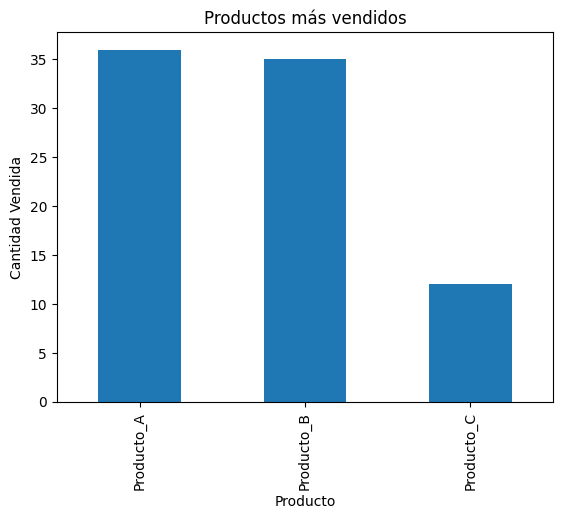

In [ ]:
import matplotlib.pyplot as plt

productos = datos_ventas.groupby('Producto')['Cantidad'].sum()

productos.plot(kind='bar', title='Productos más vendidos')

plt.xlabel('Producto')
plt.ylabel('Cantidad Vendida')
plt.show()

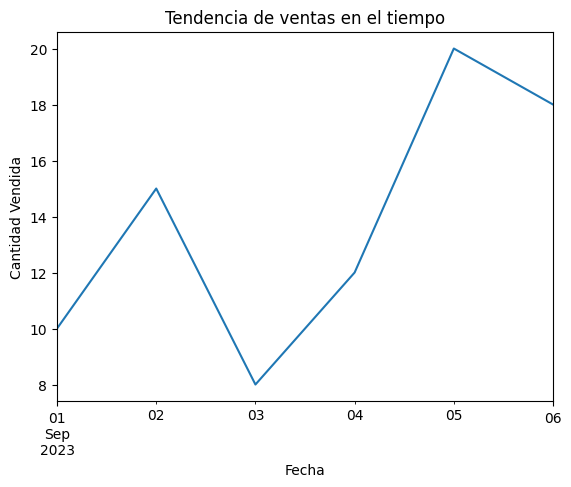

In [ ]:
ventas_fecha = datos_ventas.groupby('Fecha_Compra')['Cantidad'].sum()

ventas_fecha.plot(title='Tendencia de ventas en el tiempo')

plt.xlabel('Fecha')
plt.ylabel('Cantidad Vendida')
plt.show()

In [ ]:
# Producto con mayor venta
print("Producto más vendido:")
print(productos.idxmax(), "con", productos.max(), "unidades")

# Producto más rentable
rentabilidad = datos_ventas.groupby('Producto')['Beneficio'].sum()
print("\nProducto más rentable:")
print(rentabilidad.idxmax(), "con beneficio de", rentabilidad.max())

Producto más vendido:
Producto_A con 36 unidades

Producto más rentable:
Producto_A con beneficio de 872


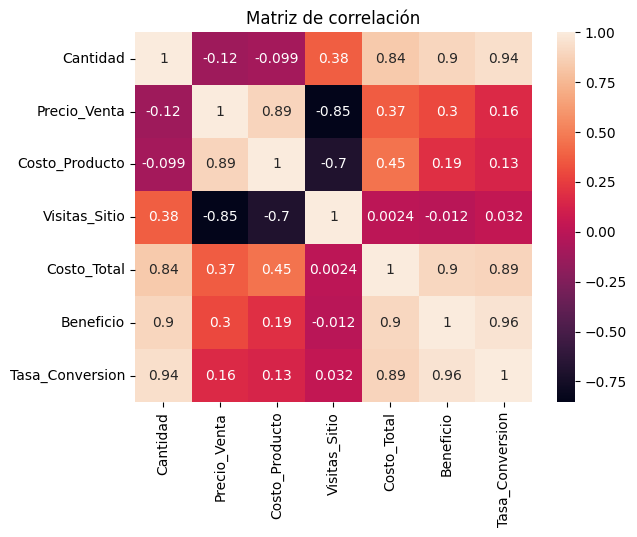

In [ ]:
# Correlación
import seaborn as sns

sns.heatmap(datos_ventas.corr(numeric_only=True), annot=True)
plt.title("Matriz de correlación")
plt.show()

##Desde mi perspectiva como estudiante, el análisis de los datos de ventas del comercio electrónico evidencia que existen diferencias claras en el desempeño de los productos, tanto en volumen de ventas como en rentabilidad. Se observa que algunos productos presentan mayor rotación, lo que indica una alta aceptación por parte de los clientes, mientras que otros, aunque se venden menos, pueden generar mayores márgenes de beneficio, lo cual es clave para la sostenibilidad del negocio.##

#Adicionalmente, el análisis temporal permite identificar que las ventas no son uniformes, sino que presentan patrones a lo largo del tiempo, lo que sugiere la existencia de comportamientos de compra que pueden ser aprovechados estratégicamente. Por otra parte, la relación entre las visitas al sitio y las ventas (tasa de conversión) evidencia que existe un margen de mejora en la eficiencia del canal digital, ya que no todas las visitas se traducen en compras efectivas.##